In [10]:
import sys
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from loss_func import loss_func_diffusion
from forward import noise_schedule, forward_process
from train_controller import train_controller_diffusion
from reversal import reverse_sde
from diffusion_architecture import Diffusion

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_root = Path("./data")
raw_dir = data_root / "FashionMNIST" / "raw"
required_files = [
    "train-images-idx3-ubyte",
    "train-labels-idx1-ubyte",
    "t10k-images-idx3-ubyte",
    "t10k-labels-idx1-ubyte",
]
should_download = not all((raw_dir / file_name).exists() for file_name in required_files)

dataset = torchvision.datasets.FashionMNIST(
    root=str(data_root),
    train=True,
    download=should_download,
    transform=transform
)

batch_size = 256
# sub_dataset = torch.utils.data.Subset(dataset, range(500))
# loader = torch.utils.data.DataLoader(sub_dataset, batch_size=batch_size, shuffle=True)

loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Loader num_batches: {len(loader)}")
print(f"Loader batch_shape: {next(iter(loader))[0].shape}")

Loader num_batches: 235
Loader batch_shape: torch.Size([256, 1, 28, 28])


In [12]:
# variables

EPOCHS = 200
lr = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sample_x, _ = loader.dataset[0]
input_dim = sample_x.numel()
mlp_hidden = (512, 256, 128, 256, 512)
t_hidden_dim = 128
output_dim = input_dim
T = 1000
t_max = 1000

every_n_epochs = 20

Using device: cuda


In [13]:
conv_hidden = (32, 64, 128, 64, 32)
model = Diffusion(input_dim=input_dim, mlp_hidden=mlp_hidden, conv_hidden=conv_hidden, t_hidden_dim=t_hidden_dim, output_dim=output_dim, use_conv=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_controller_diffusion(
    model,
    train_loader=loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    t_max=t_max, T=T,
    every_n_epochs=every_n_epochs,
    device=device,

    noise_schedule=noise_schedule,
    loss_func=loss_func_diffusion, 
)

beta_integral final: 10.040050506591797
mean coeff final: 0.0066043599508702755
var final: 0.9999563694000244
0: 186.79218816757202
20: 79.01750442385674
40: 74.06127390265465
60: 69.06357777118683
80: 66.53972607851028
100: 66.22882981598377
120: 66.62709131836891
140: 64.16803924739361
160: 63.53465919196606
180: 67.18105378746986


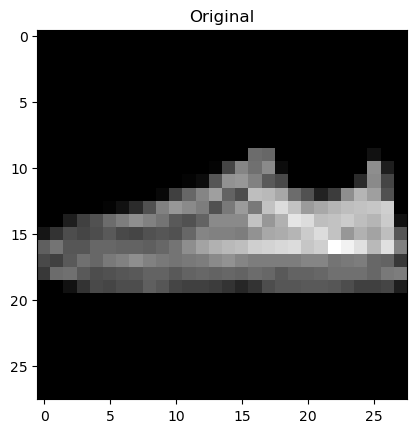

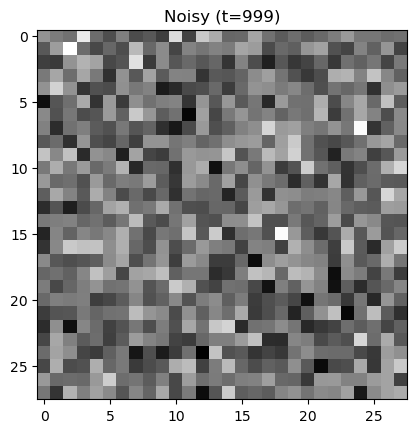

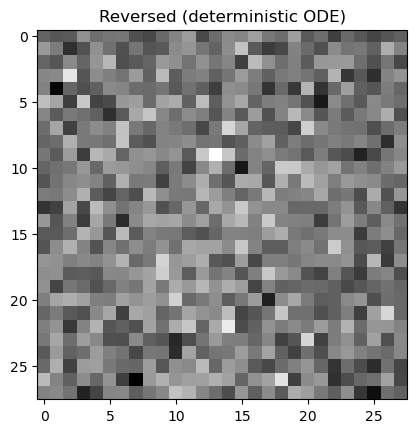

MSE(noisy, original):   1.651586
MSE(reversed, original): 0.865678


In [ ]:
import matplotlib.pyplot as plt
from forward import forward_process
from reversal import reverse_sde

"""
Testing the model
- Show original image
- Use forward to add noise to the image
- Reverse with deterministic sampler first
"""
model.eval()
model.to('cpu')

# Get a batch of data
data_iter = iter(loader)
images, _ = next(data_iter)
image = images[0].unsqueeze(0).to('cpu')

# Show original image
plt.imshow(image.squeeze().numpy(), cmap='gray')
plt.title('Original')
plt.show()

# Start with a milder noise level to verify denoising direction
sample_t = min(1000, t_max - 1)
t_all = torch.arange(t_max, dtype=torch.float32)
beta_all = noise_schedule(t_all, T)
beta_cumsum = torch.cumsum(beta_all, dim=0) * (1.0 / T)

batch_betas = beta_cumsum[sample_t].unsqueeze(0).repeat(image.size(0), 1)
noisy_image = forward_process(image, sample_t, T, noise_schedule, batch_betas, device='cpu')
plt.imshow(noisy_image.squeeze().numpy().reshape(28, 28), cmap='gray')
plt.title(f'Noisy (t={sample_t})')
plt.show()

# Deterministic reverse from matching start time
reversed_image = reverse_sde(model, noisy_image, t_start=sample_t, T=T, noise_schedule=noise_schedule).view(28, 28)
plt.imshow(reversed_image.detach().numpy().reshape(28, 28), cmap='gray')
plt.title('Reversed (deterministic ODE)')
plt.show()

orig_flat = image.view(1, -1)
noisy_flat = noisy_image.view(1, -1)
rev_flat = reversed_image.view(1, -1)

mse_noisy = torch.mean((noisy_flat - orig_flat) ** 2).item()
mse_reversed = torch.mean((rev_flat - orig_flat) ** 2).item()
print(f'MSE(noisy, original):   {mse_noisy:.6f}')
print(f'MSE(reversed, original): {mse_reversed:.6f}')